In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

Total frames: 876


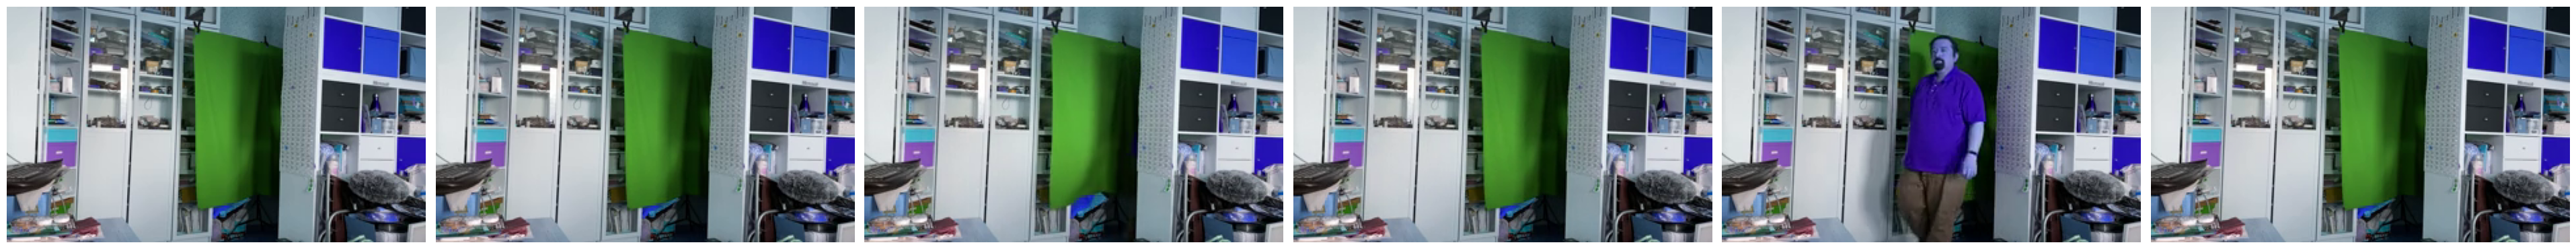

In [4]:
vid = cv2.VideoCapture('data/motionvideo.mp4')

c = 0
frames = []
while vid.isOpened():
    ret, frame = vid.read()
    if not ret:
        break
    frames.append(frame)
    c+=1
vid.release()
print(f"Total frames: {c}")
display_images(frames[::150])

Since color is not so important for motion detection, we will convert all frames to grayscale. Then, we will compute the frame differences, and plot their norms to visually see the amount of activity going on

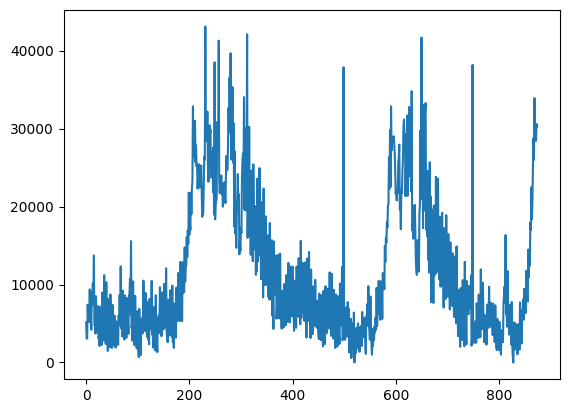

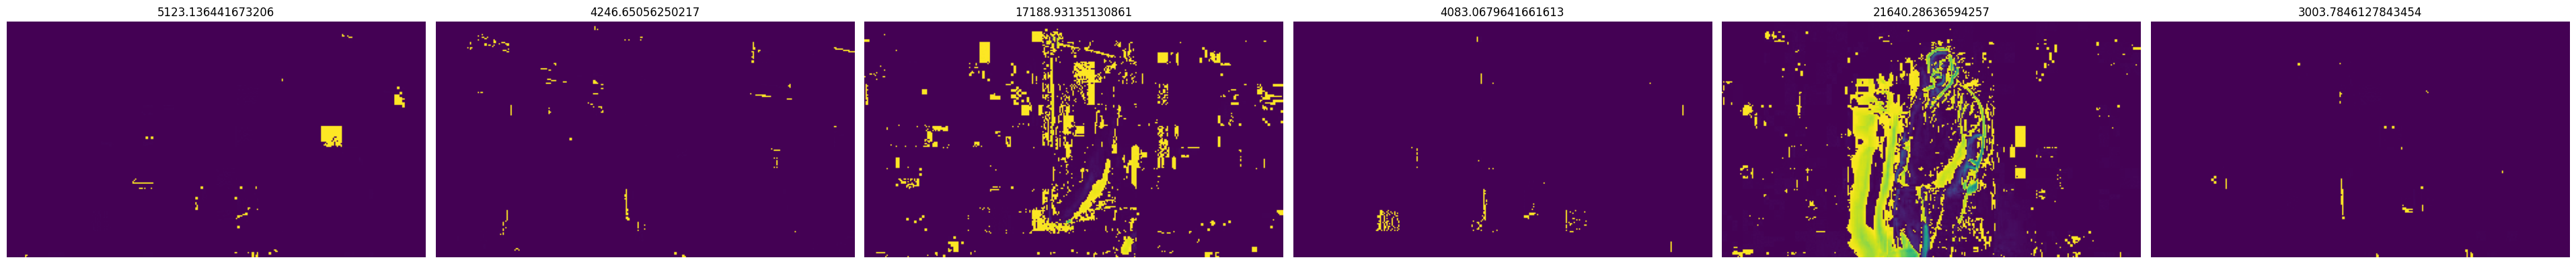

In [5]:
bwframes = [cv2.cvtColor(x,cv2.COLOR_BGR2GRAY) for x in frames]
diffs = [(p2-p1) for p1,p2 in zip(bwframes[:-1],bwframes[1:])]
diff_amps = np.array([np.linalg.norm(x) for x in diffs])
plt.plot(diff_amps)
display_images(diffs[::150],titles=diff_amps[::150])

Suppose we want to create a report that shows what happened in front of the camera by showing the suitable image each time something happens. To do it, we probably want to find out the start and end frame of an "event", and display the middle frame. To remove some noise, we will also smooth out the curve above with moving average function

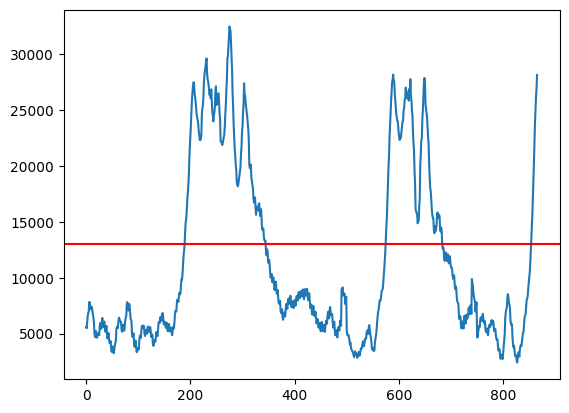

In [6]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

threshold = 13000

plt.plot(moving_average(diff_amps,10))
plt.axhline(y=threshold, color='r', linestyle='-')

Now we can find out frames that have the amount of changes above the threshold by using np.where, and extract a sequence of consecutive frames that is longer than 30 frames

In [8]:
active_frames = np.where(diff_amps>threshold)[0]

def subsequence(seq,min_length=30):
    ss = []
    for i,x in enumerate(seq[:-1]):
        ss.append(x)
        if x+1 != seq[i+1]:
            if len(ss)>min_length:
                return ss
            ss.clear()

sub = subsequence(active_frames)
print(sub)

[np.int64(195), np.int64(196), np.int64(197), np.int64(198), np.int64(199), np.int64(200), np.int64(201), np.int64(202), np.int64(203), np.int64(204), np.int64(205), np.int64(206), np.int64(207), np.int64(208), np.int64(209), np.int64(210), np.int64(211), np.int64(212), np.int64(213), np.int64(214), np.int64(215), np.int64(216), np.int64(217), np.int64(218), np.int64(219), np.int64(220), np.int64(221), np.int64(222), np.int64(223), np.int64(224), np.int64(225), np.int64(226), np.int64(227), np.int64(228), np.int64(229), np.int64(230), np.int64(231), np.int64(232), np.int64(233), np.int64(234), np.int64(235), np.int64(236), np.int64(237), np.int64(238), np.int64(239), np.int64(240), np.int64(241), np.int64(242), np.int64(243), np.int64(244), np.int64(245), np.int64(246), np.int64(247), np.int64(248), np.int64(249), np.int64(250), np.int64(251), np.int64(252), np.int64(253), np.int64(254), np.int64(255), np.int64(256), np.int64(257), np.int64(258), np.int64(259), np.int64(260), np.int64(

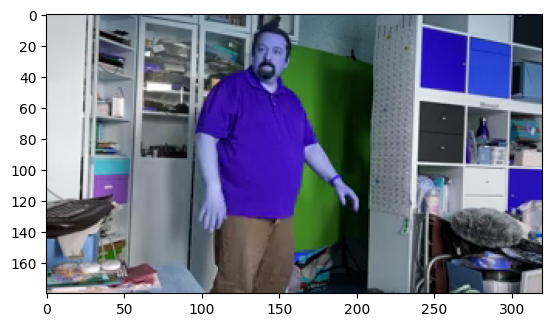

In [9]:
plt.imshow(frames[(sub[0]+sub[-1])//2])

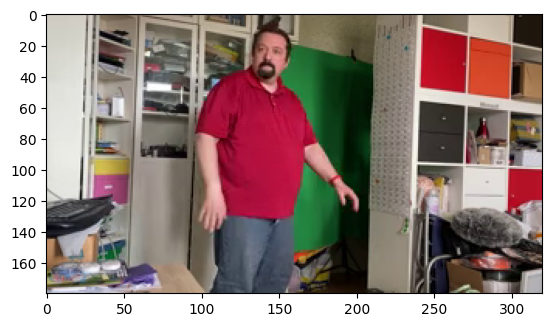

In [10]:
plt.imshow(cv2.cvtColor(frames[(sub[0]+sub[-1])//2],cv2.COLOR_BGR2RGB))